# **Dataset Airline Passenger Satisfaction**

In [ ]:
import pandas as pd
import numpy as np # Import numpy for linspace
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from imblearn.over_sampling import SMOTE

In [ ]:

# Load dataset
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/New Dataset/Airline Passenger Satisfaction.csv')

In [ ]:
# Display the first few rows
print("First Few Rows:\n", df.head())


First Few Rows:
    Unnamed: 0      id  Gender      Customer Type  Age   Type of Travel  \
0           0   70172    Male     Loyal Customer   13  Personal Travel   
1           1    5047    Male  disloyal Customer   25  Business travel   
2           2  110028  Female     Loyal Customer   26  Business travel   
3           3   24026  Female     Loyal Customer   25  Business travel   
4           4  119299    Male     Loyal Customer   61  Business travel   

      Class  Flight Distance  Inflight wifi service  \
0  Eco Plus              460                      3   
1  Business              235                      3   
2  Business             1142                      2   
3  Business              562                      2   
4  Business              214                      3   

   Departure/Arrival time convenient  ...  Inflight entertainment  \
0                                  4  ...                       5   
1                                  2  ...                       1   


In [ ]:
# Display the last few rows
print("\nLast Few Rows:\n", df.tail())


Last Few Rows:
         Unnamed: 0     id  Gender      Customer Type  Age   Type of Travel  \
103899      103899  94171  Female  disloyal Customer   23  Business travel   
103900      103900  73097    Male     Loyal Customer   49  Business travel   
103901      103901  68825    Male  disloyal Customer   30  Business travel   
103902      103902  54173  Female  disloyal Customer   22  Business travel   
103903      103903  62567    Male     Loyal Customer   27  Business travel   

           Class  Flight Distance  Inflight wifi service  \
103899       Eco              192                      2   
103900  Business             2347                      4   
103901  Business             1995                      1   
103902       Eco             1000                      1   
103903  Business             1723                      1   

        Departure/Arrival time convenient  ...  Inflight entertainment  \
103899                                  1  ...                       2   
10390

In [ ]:
# Check for missing values
print("\nMissing Values:\n", df.isnull().sum())


Missing Values:
 Unnamed: 0                             0
id                                     0
Gender                                 0
Customer Type                          0
Age                                    0
Type of Travel                         0
Class                                  0
Flight Distance                        0
Inflight wifi service                  0
Departure/Arrival time convenient      0
Ease of Online booking                 0
Gate location                          0
Food and drink                         0
Online boarding                        0
Seat comfort                           0
Inflight entertainment                 0
On-board service                       0
Leg room service                       0
Baggage handling                       0
Checkin service                        0
Inflight service                       0
Cleanliness                            0
Departure Delay in Minutes             0
Arrival Delay in Minutes             31

In [ ]:
# Handle missing values (example: fill with mean for numerical, mode for categorical)
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].fillna(df[col].mode()[0])
    else:
      df[col] = df[col].fillna(df[col].mean())

In [ ]:
# Select numerical columns for boxplot
numerical_cols = df.select_dtypes(include=['number']).columns

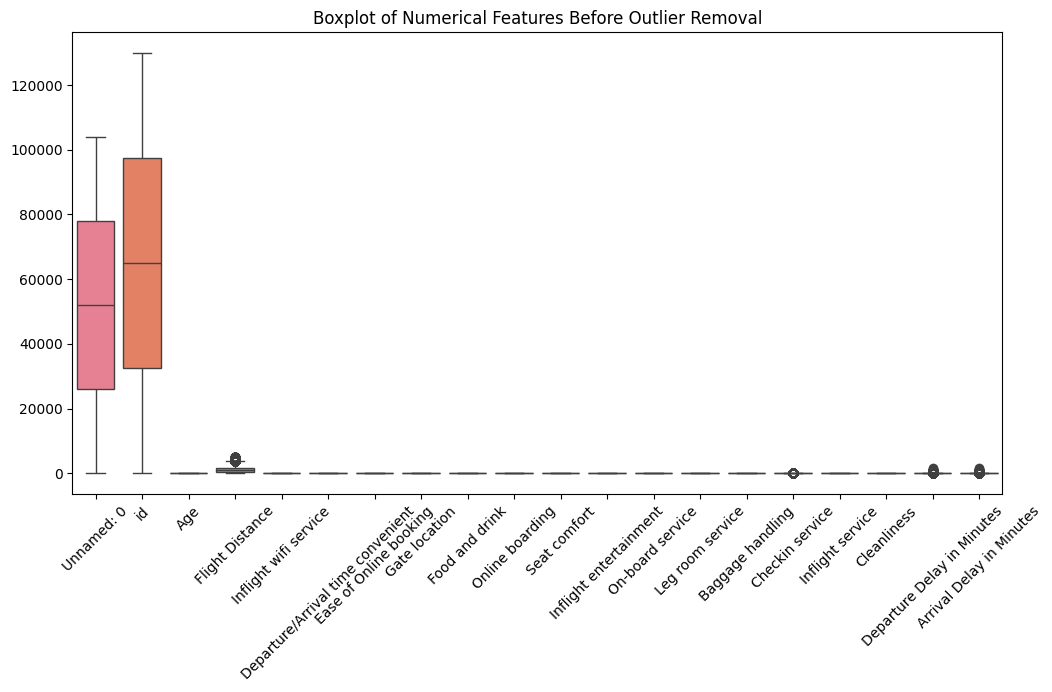

In [ ]:
# Create a combined boxplot
plt.figure(figsize=(12, 6))
sns.boxplot(data=df[numerical_cols]) # Changed numerical_features to df[numerical_cols]
plt.xticks(rotation=45)
plt.title('Boxplot of Numerical Features Before Outlier Removal')
plt.show()

In [ ]:
# Function to remove outliers using IQR
def remove_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df = df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]
    return df
# Remove outliers for each numerical column
for col in numerical_cols:
    df = remove_outliers_iqr(df, col)

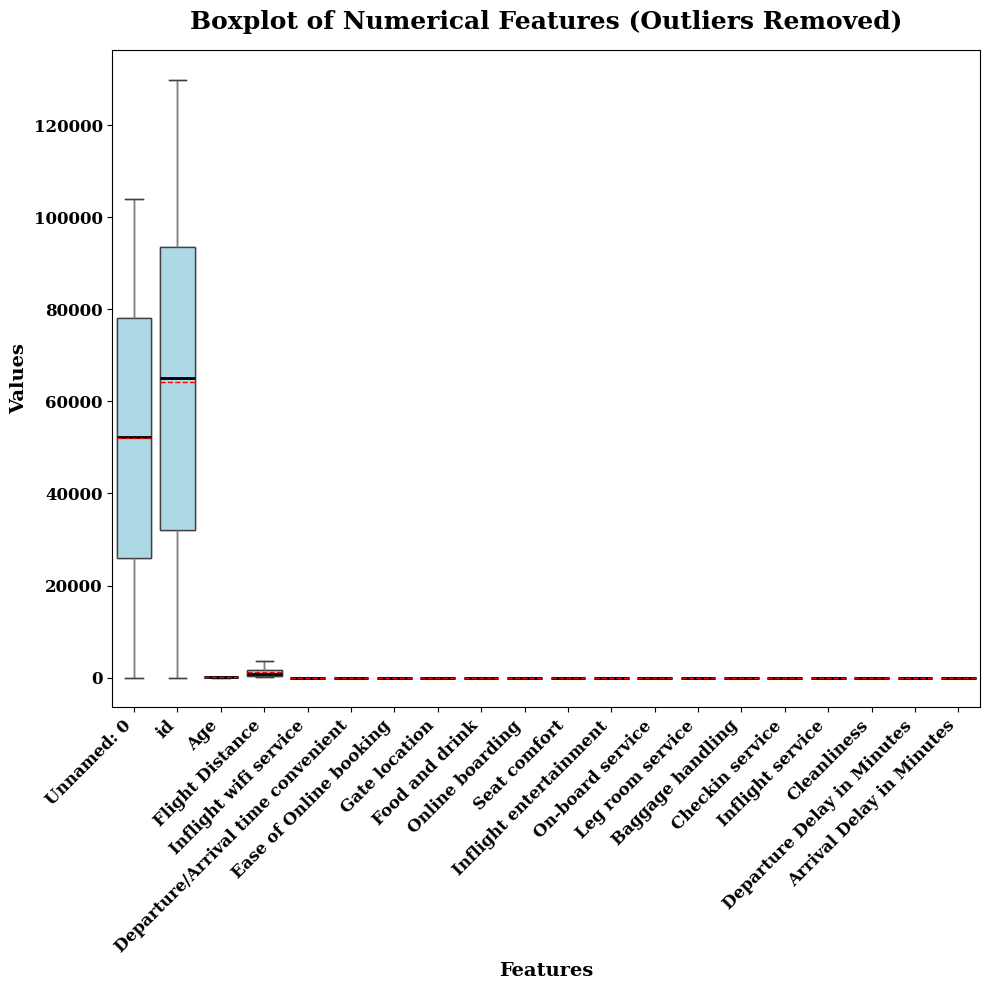

In [ ]:
# Plot a combined boxplot of all numerical features after outlier removal
plt.figure(figsize=(10, 10))
sns.boxplot(data=df[numerical_cols], palette="coolwarm")  # Color scheme added

sns.boxplot(data=df[numerical_cols],

            showmeans=True,  # Show the mean of each feature
            meanline=True,   # Represent the mean as a line
            meanprops={'color': 'red', 'linestyle': '--'},  # Style the mean line
            medianprops={'color': 'black', 'linewidth': 2},  # Style the median line
            boxprops={'facecolor': 'lightblue'},  # Style the box
            whiskerprops={'color': 'gray'},  # Style the whiskers
            flierprops={'marker': 'o', 'markerfacecolor': 'red', 'markersize': 8}  # Style the outliers
            )
plt.title('Boxplot of Numerical Features (Outliers Removed)', fontsize=18, fontweight='bold', fontfamily="serif", pad=15)
plt.xlabel("Features", fontsize=14, fontweight='bold', fontfamily="serif")
plt.ylabel("Values", fontsize=14, fontweight='bold', fontfamily="serif")
plt.xticks(rotation=45, ha='right', fontsize=12, fontweight='bold', fontfamily="serif", color="black")
plt.yticks(fontsize=12, fontweight='bold', fontfamily="serif", color="black")
plt.tight_layout()
plt.show()

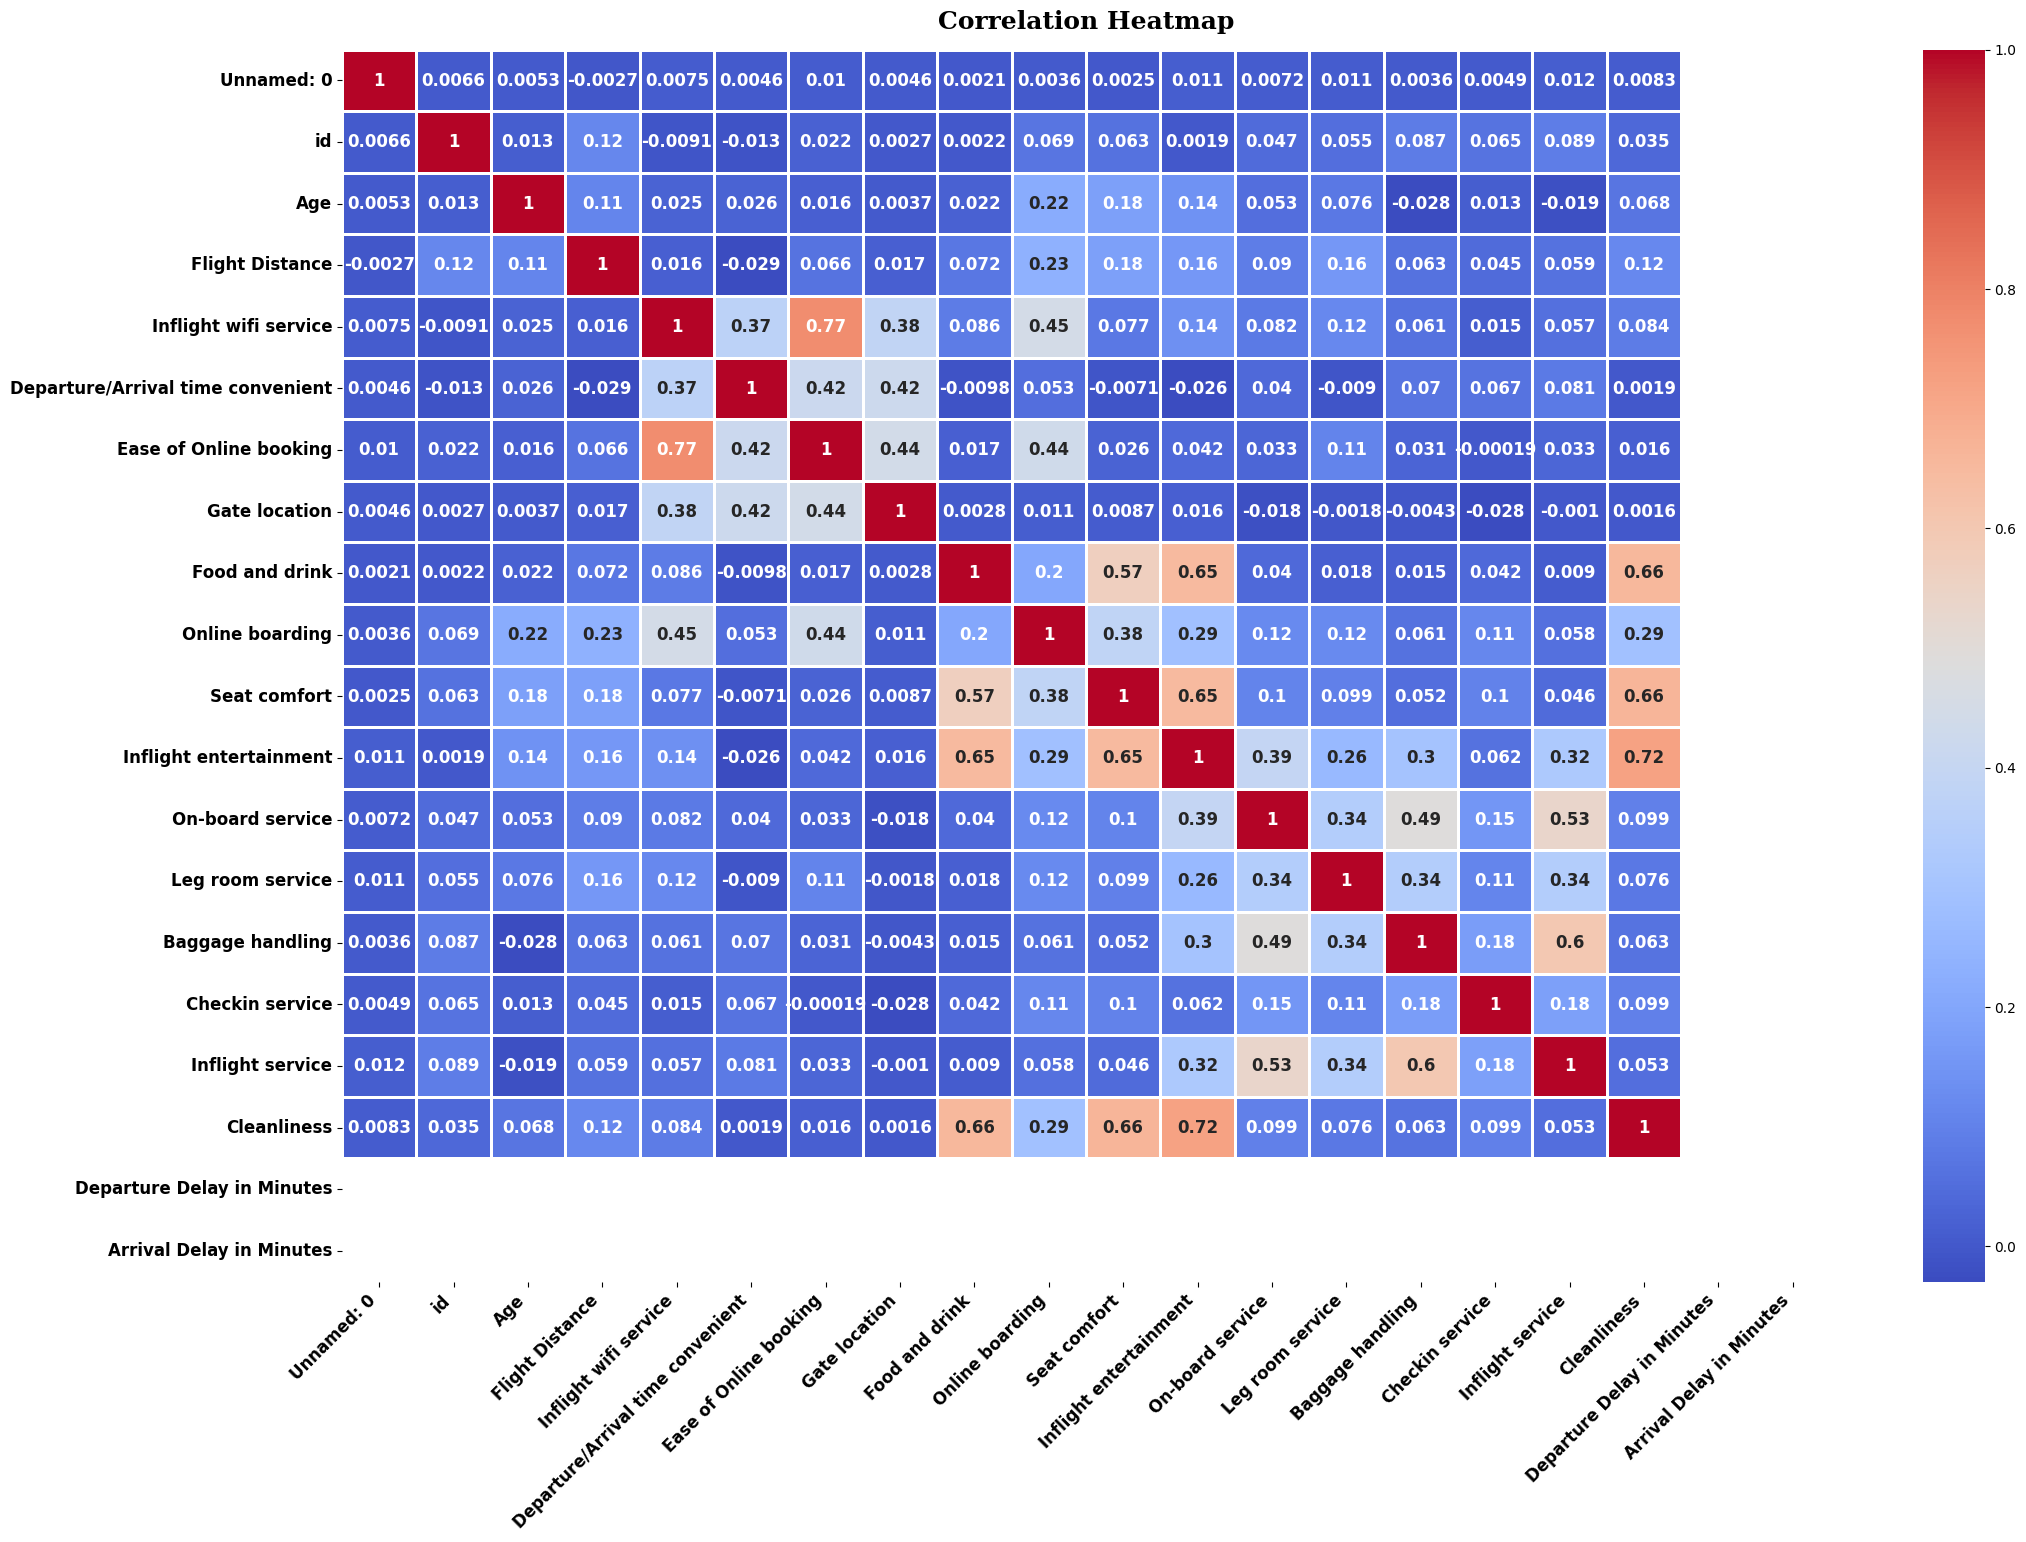

In [ ]:
# Draw a correlation heatmap
plt.figure(figsize=(24, 16))
# Select only numerical features for correlation calculation
numerical_df = df.select_dtypes(include=['number'])
heatmap = sns.heatmap(numerical_df.corr(), annot=True, cmap='coolwarm',
            linewidths=1, linecolor='white',  # Change linecolor to white
            annot_kws={"size": 12, "weight": "bold"})  # Increase font size and make it bold
plt.title('Correlation Heatmap', fontsize=18, fontweight='bold', fontfamily="serif", pad=15)  # Style the title

# Rotate x-axis labels
heatmap.set_xticklabels(heatmap.get_xticklabels(), rotation=45, ha='right', fontsize=12, weight='bold')
heatmap.set_yticklabels(heatmap.get_yticklabels(), fontsize=12, weight='bold')  # Style y-axis labels

plt.show()

# **Ya dataset kafi bara tha is lia is mai sa sirf Subnet ka important columns pick kia hai because runtime crash hou rha tha bar bar Baki Check kia hai is sa model traning par koi Farq nhi parta because Unecessary Colums drop kia hai**

In [ ]:
# Drop unnecessary columns
df_clean = df.drop(columns=['Unnamed: 0', 'id']).dropna().copy()

# Convert categorical target variable into numerical (avoid SettingWithCopyWarning)
df_clean.loc[:, 'satisfaction'] = df_clean['satisfaction'].map({'satisfied': 1, 'neutral or dissatisfied': 0})

# Ensure all columns are numeric
df_clean = df_clean.apply(pd.to_numeric, errors='coerce')

# Select a subset of important numeric columns to prevent slow execution
selected_features = ['Age', 'Flight Distance', 'Departure Delay in Minutes', 'Arrival Delay in Minutes', 'satisfaction']

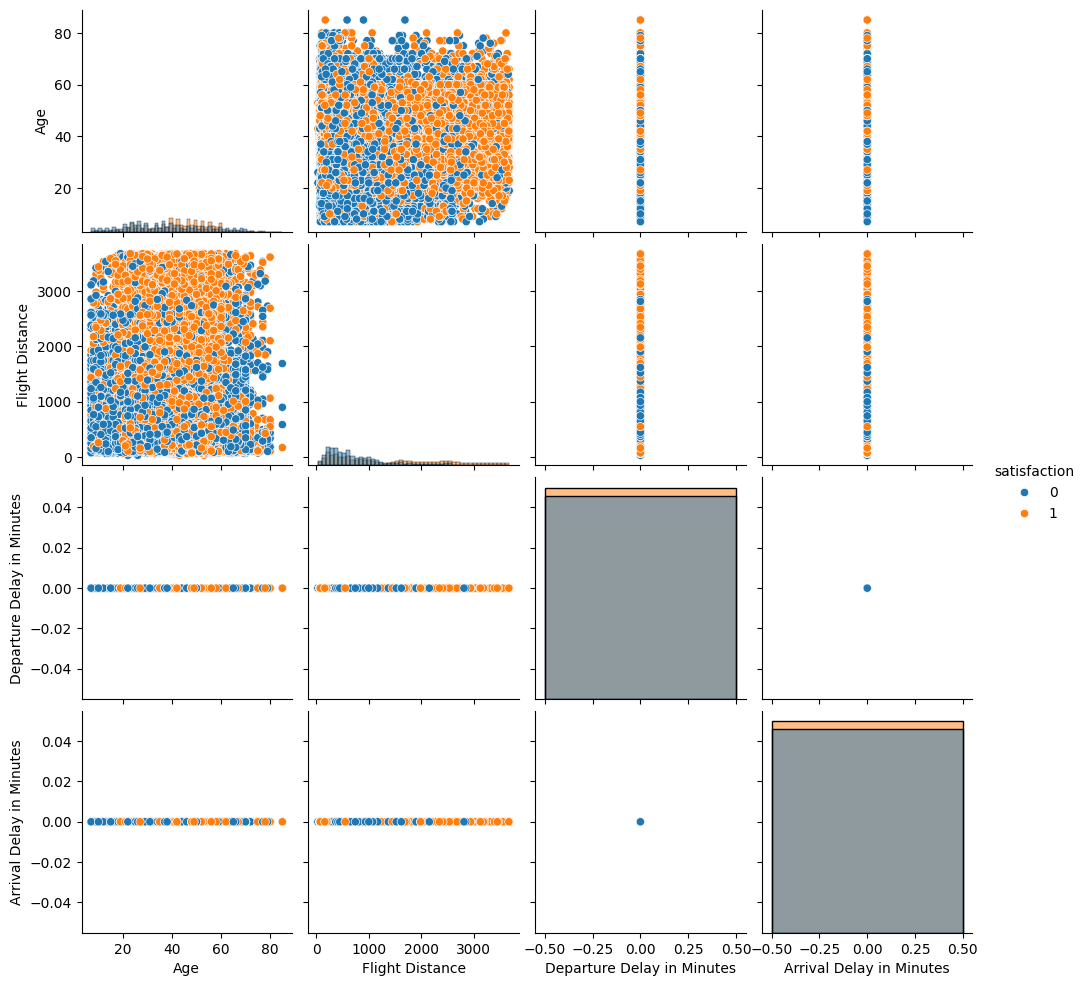

In [ ]:
# Generate pair plot
sns.pairplot(df_clean[selected_features], hue='satisfaction', diag_kind='hist')
plt.show()

In [ ]:
# Initialize LabelEncoder
label_encoder = LabelEncoder()

# Iterate through each column in the DataFrame
for column in df_clean.columns:
    # Check if the column's data type is 'object' (categorical)
    if df_clean[column].dtype == 'object':
        # Fit and transform the column using LabelEncoder
        df_clean[column] = label_encoder.fit_transform(df_clean[column])

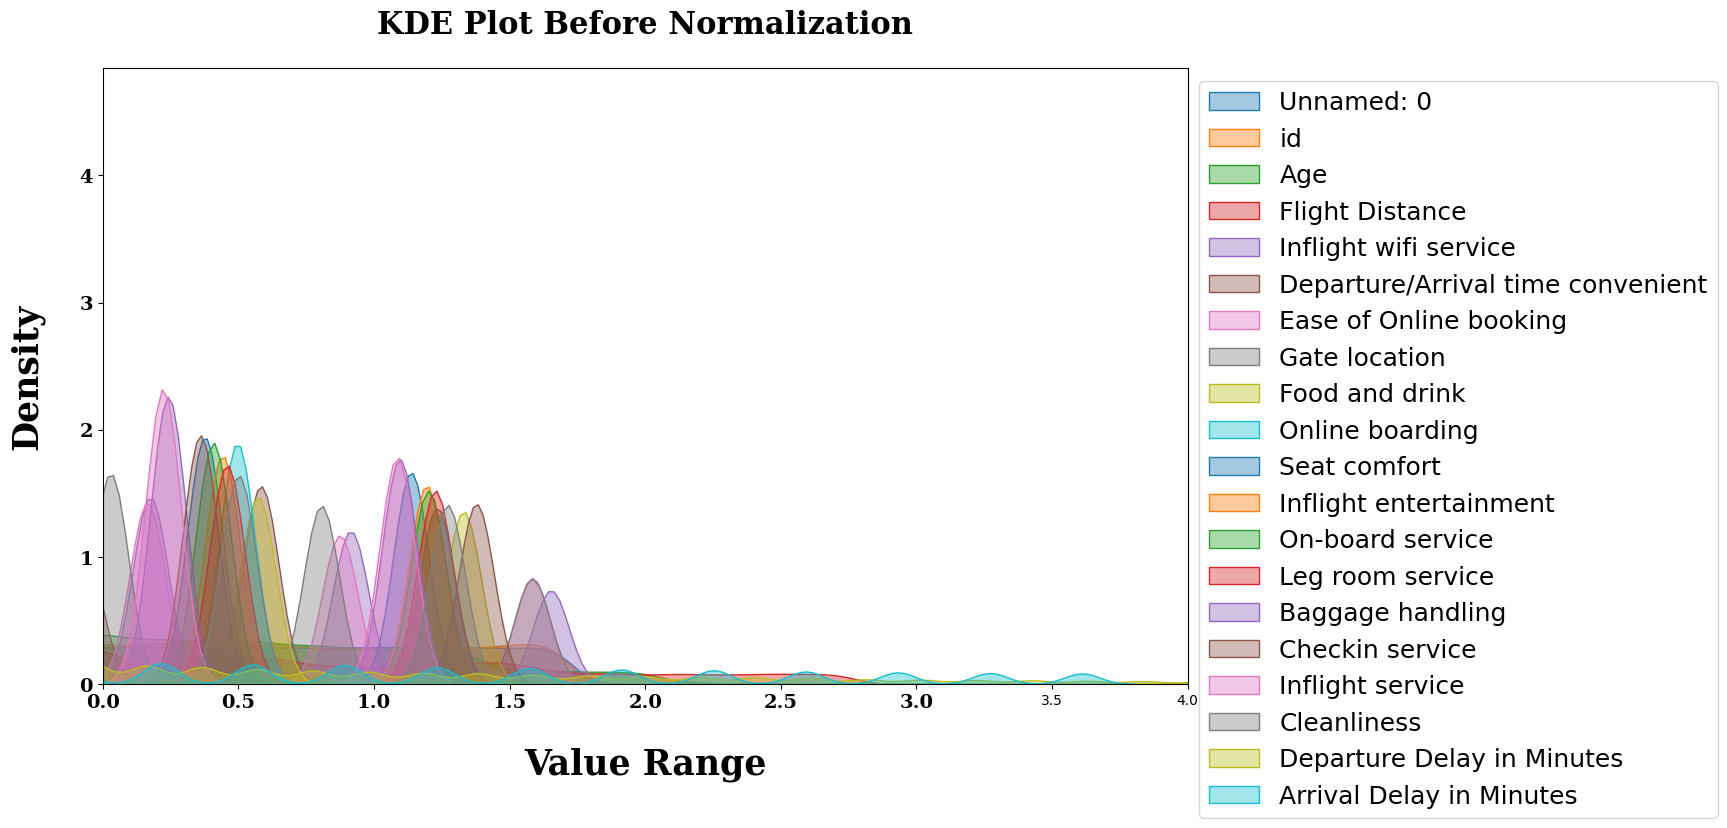

In [ ]:
# Ensure dataframe is defined and has no NaN values
df_cleaned = df.dropna()

plt.figure(figsize=(14, 8))

# Get numerical columns
numerical_cols = df_cleaned.select_dtypes(include=['number']).columns

# Normalize Data
df_cleaned[numerical_cols] = df_cleaned[numerical_cols].apply(lambda x: (x - x.mean()) / x.std())

# KDE Plot
for col in numerical_cols:
    sns.kdeplot(df_cleaned[col], label=col, fill=True, alpha=0.4, bw_adjust=0.6)

# Titles & Labels
plt.title("KDE Plot Before Normalization", fontsize=22, fontweight='bold', fontfamily="serif", pad=25)
plt.xlabel("Value Range", fontsize=25, fontweight='bold', fontfamily="serif", labelpad=25)
plt.ylabel("Density", fontsize=25, fontweight='bold', fontfamily="serif", labelpad=25)

# Ticks & Limits
plt.xticks(fontsize=14, fontweight='bold', fontfamily="serif", color="black")
plt.yticks(fontsize=14, fontweight='bold', fontfamily="serif", color="black")
plt.xlim(0, 4)  # Adjust range based on data

# Legend
plt.legend(fontsize=18, loc="upper right", bbox_to_anchor=(1.5, 1))

plt.show()

In [ ]:
# Perform normalization
scaler = StandardScaler()
df[numerical_cols] = scaler.fit_transform(df[numerical_cols])

<ipython-input-24-9d1a2986f96f>:5: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(df[col], label=col, fill=True, alpha=0.4, bw_adjust=0.6)  # Fill + Transparency
<ipython-input-24-9d1a2986f96f>:5: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(df[col], label=col, fill=True, alpha=0.4, bw_adjust=0.6)  # Fill + Transparency


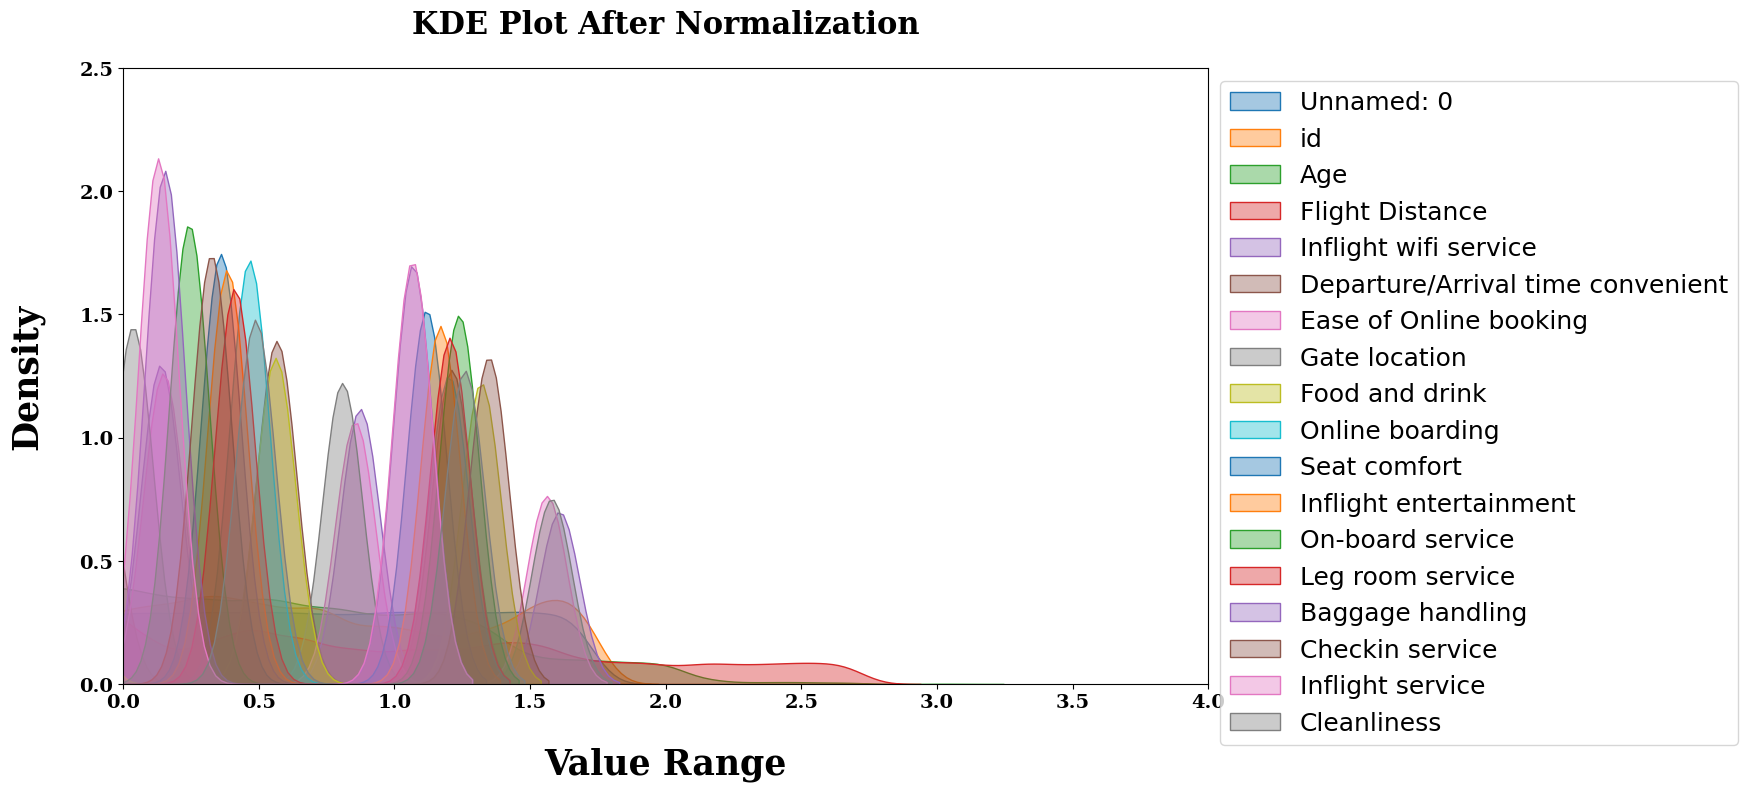

In [ ]:
# Plot KDE graph after normalization
plt.figure(figsize=(14, 8))  # Changed figure size

for col in numerical_cols:
    sns.kdeplot(df[col], label=col, fill=True, alpha=0.4, bw_adjust=0.6)  # Fill + Transparency

# Updated Titles & Labels
plt.title("KDE Plot After Normalization", fontsize=22, fontweight='bold', fontfamily="serif", pad=25)
plt.xlabel("Value Range", fontsize=25, fontweight='bold', fontfamily="serif", labelpad=25)
plt.ylabel("Density", fontsize=25, fontweight='bold', fontfamily="serif", labelpad=25)

# Updated Ticks & Limits
plt.xticks(fontsize=14, fontweight='bold', fontfamily="serif", color="black")
plt.yticks(fontsize=14, fontweight='bold', fontfamily="serif", color="black")
plt.xlim(0, 4)  # Changed x-axis limit
plt.ylim(0, 2.5)
# Updated Legend
plt.legend(fontsize=18, loc="upper right", bbox_to_anchor=(1.5, 1))  # Legend moved right

plt.show()

<ipython-input-21-a22ff621bbc0>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='satisfaction', data=df, palette="coolwarm")  # Add palette="coolwarm"


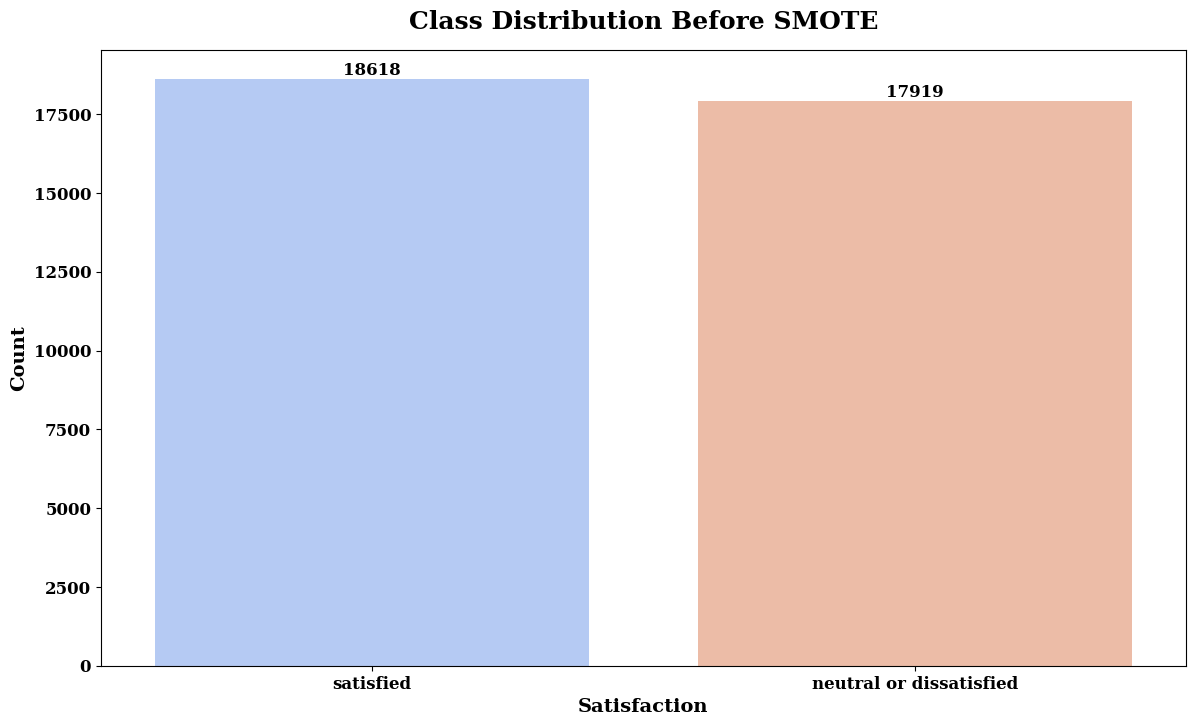

In [ ]:
# Assuming 'satisfaction' is your target variable (replace if different)
# Plot class distribution before applying SMOTE
plt.figure(figsize=(14, 8))
sns.countplot(x='satisfaction', data=df, palette="coolwarm")  # Add palette="coolwarm"

# Add value labels on top of bars without decimal points
for p in plt.gca().patches:
    plt.gca().annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                        ha='center', va='bottom', fontsize=12, fontweight='bold', fontfamily="serif", color="black")

plt.title('Class Distribution Before SMOTE', fontsize=18, fontweight='bold', fontfamily="serif", pad=15)
plt.xlabel("Satisfaction", fontsize=14, fontweight='bold', fontfamily="serif")
plt.ylabel("Count", fontsize=14, fontweight='bold', fontfamily="serif")
plt.xticks(fontsize=12, fontweight='bold', fontfamily="serif", color="black")
plt.yticks(fontsize=12, fontweight='bold', fontfamily="serif", color="black")
plt.show()

In [ ]:
# Encode categorical features
df_encoded = df.copy()
label_encoders = {}

for col in df_encoded.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])
    label_encoders[col] = le  # Store encoders in case you need to decode later



In [ ]:
# Separate features and target
x = df_encoded.drop('satisfaction', axis=1)
y = df_encoded['satisfaction']


In [ ]:
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
# Apply SMOTE
smote = SMOTE()
x_smote, y_smote = smote.fit_resample(x, y)

# Create a new DataFrame
df_smote = pd.concat([pd.DataFrame(x_smote, columns=x.columns), pd.DataFrame(y_smote, columns=['satisfaction'])], axis=1)

<ipython-input-25-02ae48f2dd25>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='satisfaction', data=df_smote, palette="coolwarm")  # Add palette


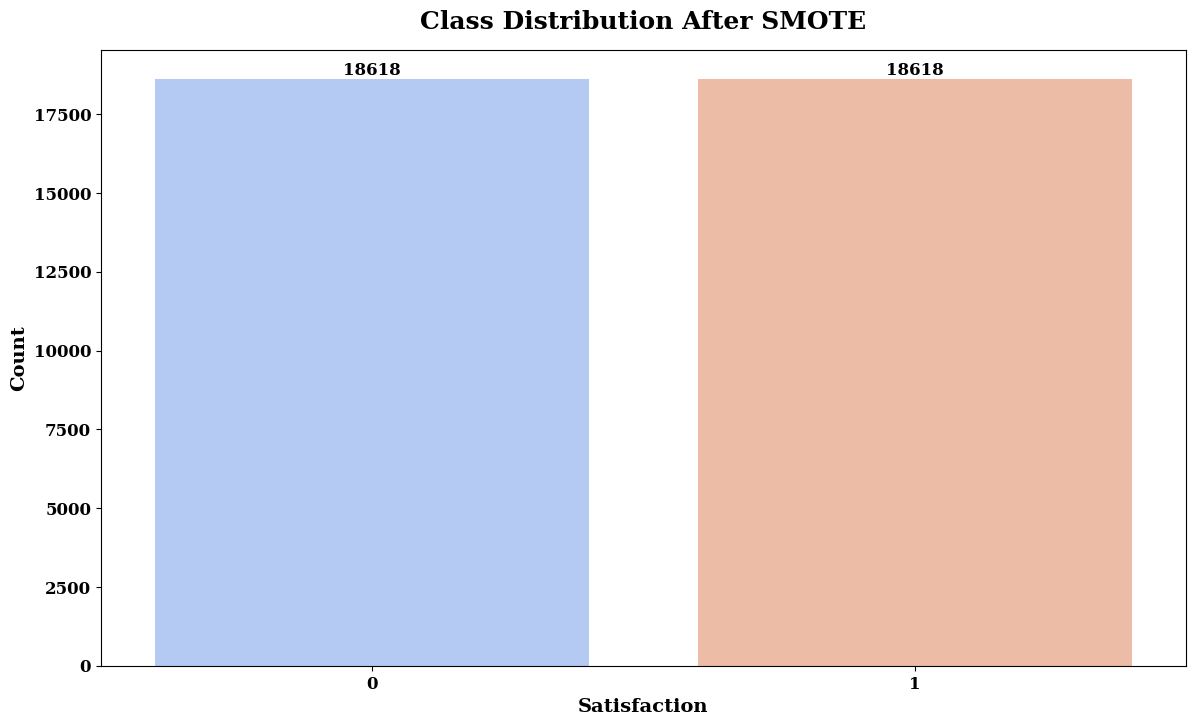

In [ ]:
# Plot class distribution after applying SMOTE
plt.figure(figsize=(14, 8))
sns.countplot(x='satisfaction', data=df_smote, palette="coolwarm")  # Add palette

# Add value labels on top of bars without decimal points
for p in plt.gca().patches:
    plt.gca().annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                        ha='center', va='bottom', fontsize=12, fontweight='bold', fontfamily="serif", color="black")

plt.title('Class Distribution After SMOTE', fontsize=18, fontweight='bold', fontfamily="serif", pad=15)
plt.xlabel("Satisfaction", fontsize=14, fontweight='bold', fontfamily="serif")
plt.ylabel("Count", fontsize=14, fontweight='bold', fontfamily="serif")
plt.xticks(fontsize=12, fontweight='bold', fontfamily="serif", color="black")
plt.yticks(fontsize=12, fontweight='bold', fontfamily="serif", color="black")
plt.show()

# **1st Model LogisticRegression**

In [ ]:
import time
import shap
!pip install lime
import lime.lime_tabular
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, classification_report,
                             roc_curve, roc_auc_score, confusion_matrix,
                             ConfusionMatrixDisplay, matthews_corrcoef)
from sklearn.model_selection import cross_val_score, train_test_split # Import train_test_split
from sklearn.preprocessing import StandardScaler # Import StandardScaler

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 2.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=a4f81a2baa1c9db0f6c9adcc950730ecbdeb6762c1479d4ce5307072e95481df
  Stored in directory: /root/.cache/pip/wheels/85/fa/a3/9c2d44c9f3cd77cf4e533b58900b2bf4487f2a17e8ec212a3d
Successfully built lime


In [ ]:
# Assuming 'df_smote' is your DataFrame after applying SMOTE
# Separate features and target
X = df_smote.drop('satisfaction', axis=1)
y = df_smote['satisfaction']

In [ ]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) # Split the data

In [ ]:
# Scale numerical features using StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train) # Fit and transform on training data
X_test_scaled = scaler.transform(X_test) # Transform test data using the fitted scaler

In [ ]:
X = df_smote.drop('satisfaction', axis=1)
y = df_smote['satisfaction']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# **-------------------------------**
# **Stage 1: Baseline Model (No Scaling)**
# **-------------------------------**

In [ ]:
start1 = time.time()
model1 = LogisticRegression(max_iter=1000)
model1.fit(X_train, y_train)
train_time1 = time.time() - start1

start_pred1 = time.time()
y_pred1 = model1.predict(X_test)
pred_time1 = time.time() - start_pred1

In [ ]:
print("\n=== Stage 1: Baseline Logistic Regression ===")
print(f"Train Accuracy: {accuracy_score(y_train, model1.predict(X_train)):.4f}")
print(f"Test Accuracy: {accuracy_score(y_test, y_pred1):.4f}")
print(f"Training Time: {train_time1:.4f} seconds")
print(f"Prediction Time: {pred_time1:.4f} seconds")
print("\nClassification Report:\n", classification_report(y_test, y_pred1))


=== Stage 1: Baseline Logistic Regression ===
Train Accuracy: 0.8760
Test Accuracy: 0.8755
Training Time: 0.1167 seconds
Prediction Time: 0.0027 seconds

Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.90      0.88      3749
           1       0.90      0.85      0.87      3699

    accuracy                           0.88      7448
   macro avg       0.88      0.88      0.88      7448
weighted avg       0.88      0.88      0.88      7448



# **-------------------------------**
# **Stage 2: Scaled Features**
# **-------------------------------**


In [ ]:
scaler2 = StandardScaler()
X_train_scaled2 = scaler2.fit_transform(X_train)
X_test_scaled2 = scaler2.transform(X_test)

In [ ]:
start2 = time.time()
model2 = LogisticRegression(max_iter=1000)
model2.fit(X_train_scaled2, y_train)
train_time2 = time.time() - start2

start_pred2 = time.time()
y_pred2 = model2.predict(X_test_scaled2)
pred_time2 = time.time() - start_pred2

In [ ]:
print("\n=== Stage 2: Scaled Features ===")
print(f"Train Accuracy: {accuracy_score(y_train, model2.predict(X_train_scaled2)):.4f}")
print(f"Test Accuracy: {accuracy_score(y_test, y_pred2):.4f}")
print(f"Training Time: {train_time2:.4f} seconds")
print(f"Prediction Time: {pred_time2:.4f} seconds")
print("\nClassification Report:\n", classification_report(y_test, y_pred2))


=== Stage 2: Scaled Features ===
Train Accuracy: 0.8761
Test Accuracy: 0.8757
Training Time: 0.1088 seconds
Prediction Time: 0.0010 seconds

Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.90      0.88      3749
           1       0.90      0.85      0.87      3699

    accuracy                           0.88      7448
   macro avg       0.88      0.88      0.88      7448
weighted avg       0.88      0.88      0.88      7448



# **-------------------------------**
# **Stage 3: Scaled + Cross-Validated Model**
# **-------------------------------**


In [ ]:
scaler3 = StandardScaler()
X_scaled_cv = scaler3.fit_transform(X)

model3 = LogisticRegression(max_iter=1000)
start3 = time.time()
cv_scores = cross_val_score(model3, X_scaled_cv, y, cv=5, scoring='accuracy')
train_time3 = time.time() - start3

In [ ]:
print("\n=== Stage 3: Scaled + Cross-Validated Logistic Regression ===")
print(f"Cross-Validation Accuracy Scores: {cv_scores}")
print(f"Mean CV Accuracy: {cv_scores.mean():.4f}")
print(f"CV Training Time: {train_time3:.4f} seconds")


=== Stage 3: Scaled + Cross-Validated Logistic Regression ===
Cross-Validation Accuracy Scores: [0.87553706 0.87458037 0.87793742 0.872029   0.8765946 ]
Mean CV Accuracy: 0.8753
CV Training Time: 0.5857 seconds


# **-------------------------------**
# **Stage 2: Scaled Features Best Accuracy**
# **-------------------------------**


In [ ]:
# Specificity
tn, fp, fn, tp = cm.ravel()
specificity = tn / (tn + fp)
print("Specificity:", specificity)


Specificity: 0.903174179781275


In [ ]:
# MCC
print("Matthews Correlation Coefficient (MCC):", matthews_corrcoef(y_test, y_pred))

Matthews Correlation Coefficient (MCC): 0.7523283810958541


In [ ]:
# Cross-validation
cv_scores = cross_val_score(lr, X, y, cv=10)
print("10-Fold CV Accuracy: %.4f ± %.4f" % (cv_scores.mean(), cv_scores.std()))

10-Fold CV Accuracy: 0.8749 ± 0.0048


In [ ]:
# Computational Complexity
print("Time Taken: %.2f seconds" % (end - start))


Time Taken: 0.05 seconds


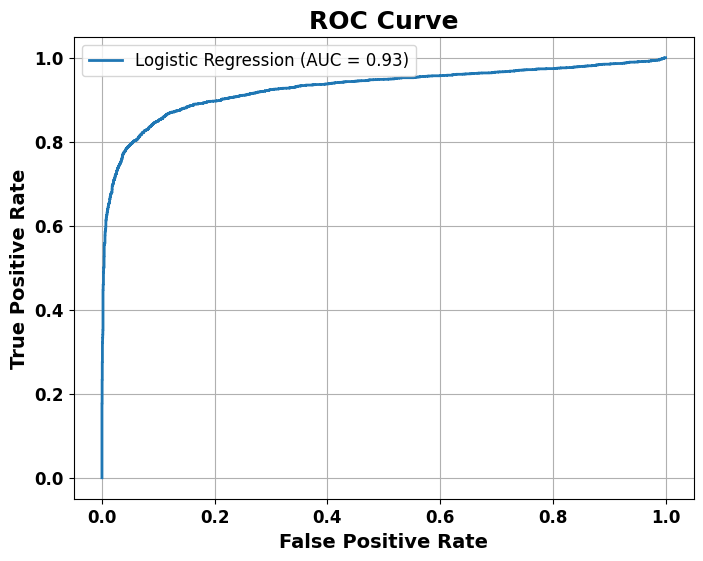

AUC Score: 0.9277


In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

# Plot
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {auc_score:.2f})', linewidth=2)

# Axis labels and title - bold and larger
plt.xlabel('False Positive Rate', fontsize=14, fontweight='bold')
plt.ylabel('True Positive Rate', fontsize=14, fontweight='bold')
plt.title('ROC Curve', fontsize=18, fontweight='bold')

# Axis ticks bold
plt.xticks(fontsize=12, fontweight='bold')
plt.yticks(fontsize=12, fontweight='bold')

# Grid and legend
plt.grid(True)
plt.legend(fontsize=12)

plt.show()

# Print AUC Score separately
print("AUC Score:", round(auc_score, 4))


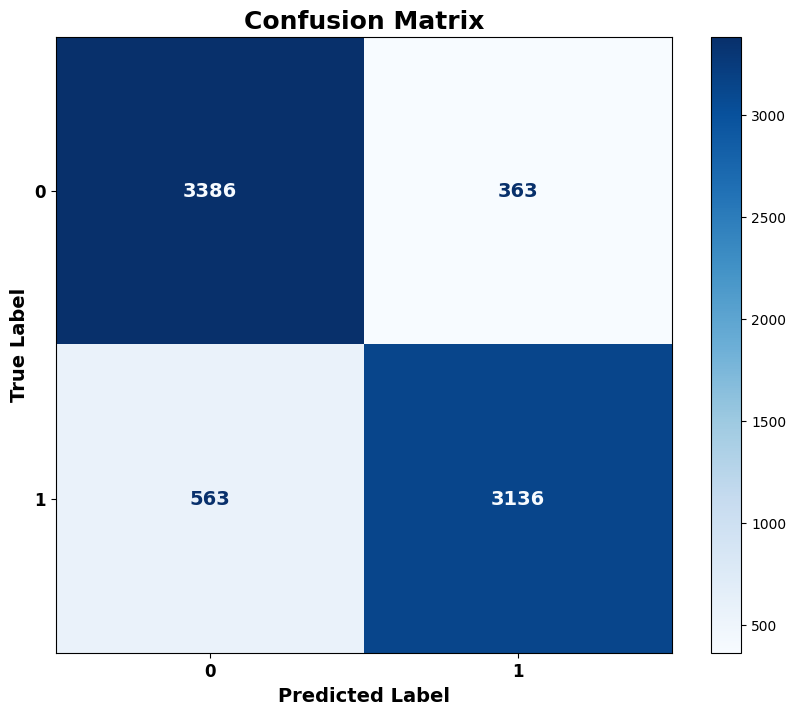

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

# Create plot
fig, ax = plt.subplots(figsize=(10, 8))
disp.plot(cmap='Blues', ax=ax, values_format='d')  # 'd' for integer display

# Bold and large title and axis labels
plt.title('Confusion Matrix', fontsize=18, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=14, fontweight='bold')

# Bold and large tick labels (0,1)
ax.set_xticklabels(ax.get_xticklabels(), fontsize=12, fontweight='bold')
ax.set_yticklabels(ax.get_yticklabels(), fontsize=12, fontweight='bold')

# Bold and large cell values
for text in disp.text_.ravel():
    text.set_fontsize(14)
    text.set_fontweight('bold')

plt.show()


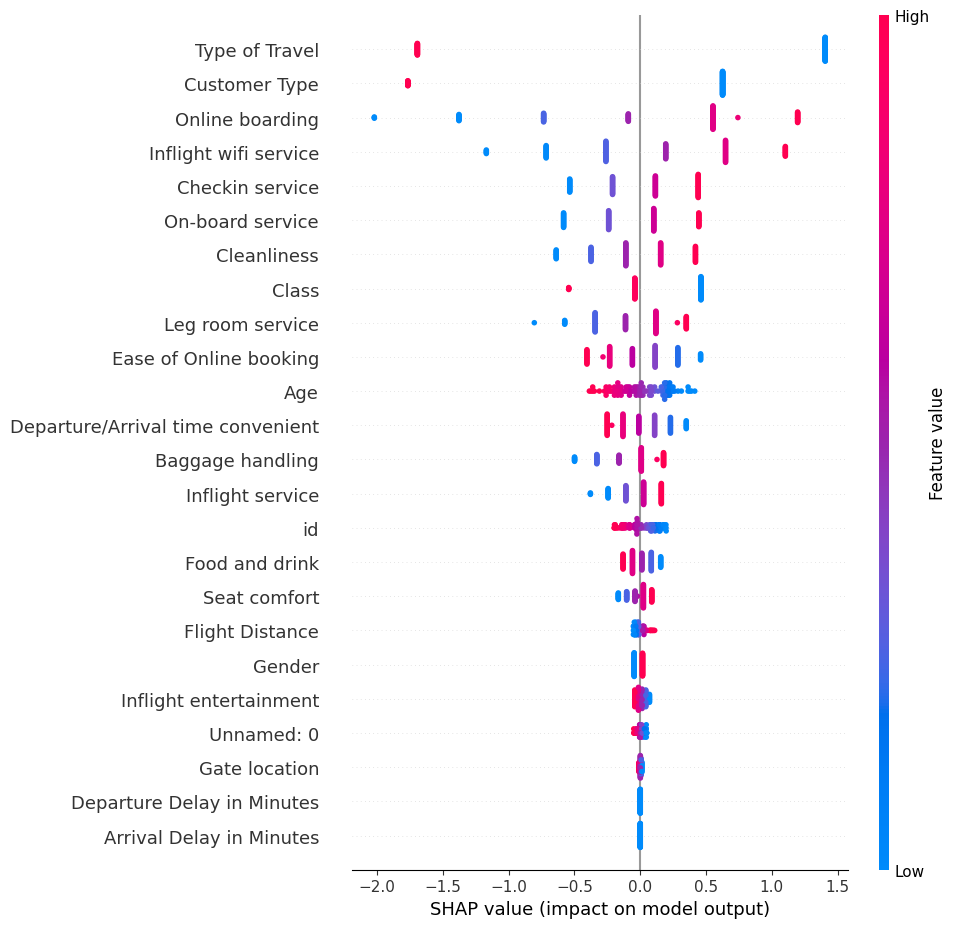

In [ ]:
# ==== SHAP Explanation ====
explainer = shap.Explainer(lr, X_train)  # Use training data as background

# Compute SHAP values for the scaled test data (must be a DataFrame with column names)
shap_values = explainer(X_test_scaled[:100])

# Generate the beeswarm plot with feature names
shap.plots.beeswarm(shap_values, max_display=len(X_train.columns))


In [ ]:
# LIME
explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train_scaled,
    feature_names=X.columns,
    class_names=["Dissatisfied", "Satisfied"],
    mode='classification'
)
exp = explainer.explain_instance(X_test_scaled[1], lr.predict_proba)
exp.show_in_notebook()


# **2nd Model Random Forest Classifier**

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report
import time

In [ ]:
# ===== Data Split =====
X = df_smote.drop('satisfaction', axis=1)
y = df_smote['satisfaction']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# **Stage 1: Baseline Random Forest (No Scaling)**

In [ ]:
start1 = time.time()
rf1 = RandomForestClassifier(random_state=42)
rf1.fit(X_train, y_train)
train_time1 = time.time() - start1

y_pred1 = rf1.predict(X_test)

In [ ]:
print("\n=== Stage 1: Baseline Random Forest ===")
print(f"Train Accuracy: {accuracy_score(y_train, rf1.predict(X_train)):.4f}")
print(f"Test Accuracy: {accuracy_score(y_test, y_pred1):.4f}")
print(f"Training Time: {train_time1:.4f} seconds")
print("\nClassification Report:\n", classification_report(y_test, y_pred1))


=== Stage 1: Baseline Random Forest ===
Train Accuracy: 1.0000
Test Accuracy: 0.9527
Training Time: 7.7544 seconds

Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.97      0.95      3749
           1       0.97      0.94      0.95      3699

    accuracy                           0.95      7448
   macro avg       0.95      0.95      0.95      7448
weighted avg       0.95      0.95      0.95      7448



# **Stage 2: Scaled Features + Random Forest**

In [ ]:
start2 = time.time()
rf2 = RandomForestClassifier(class_weight='balanced', random_state=42)
rf2.fit(X_train, y_train)
train_time2 = time.time() - start2

y_pred2 = rf2.predict(X_test)

In [ ]:
print("\n=== Stage 2: Random Forest with Class Weights ===")
print(f"Train Accuracy: {accuracy_score(y_train, rf2.predict(X_train)):.4f}")
print(f"Test Accuracy: {accuracy_score(y_test, y_pred2):.4f}")
print(f"Training Time: {train_time2:.4f} seconds")
print("\nClassification Report:\n", classification_report(y_test, y_pred2))


=== Stage 2: Random Forest with Class Weights ===
Train Accuracy: 1.0000
Test Accuracy: 0.9523
Training Time: 8.3827 seconds

Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.97      0.95      3749
           1       0.97      0.93      0.95      3699

    accuracy                           0.95      7448
   macro avg       0.95      0.95      0.95      7448
weighted avg       0.95      0.95      0.95      7448



# **Stage 3: Scaled + Cross-Validated Random Forest (Full Data)**

In [ ]:
scaler3 = StandardScaler()
X_scaled_cv = scaler3.fit_transform(X)

model3 = RandomForestClassifier(random_state=42)
start3 = time.time()
cv_scores = cross_val_score(model3, X_scaled_cv, y, cv=5, scoring='accuracy')
train_time3 = time.time() - start3


In [ ]:
print("\n=== Stage 3: Scaled + Cross-Validated Random Forest ===")
print(f"Cross-Validation Accuracy Scores: {cv_scores}")
print(f"Mean CV Accuracy: {cv_scores.mean():.4f}")
print(f"CV Training Time: {train_time3:.4f} seconds")


=== Stage 3: Scaled + Cross-Validated Random Forest ===
Cross-Validation Accuracy Scores: [0.9560956  0.94964415 0.95219551 0.95649255 0.77923996]
Mean CV Accuracy: 0.9187
CV Training Time: 27.3739 seconds


# **Stage 3: Scaled + Cross-Validated Random Forest (Full Data) Best Accuracy**

In [ ]:
# ==== Specificity & MCC ====
tn, fp, fn, tp = cm.ravel()
specificity = tn / (tn + fp)
print("Specificity:", round(specificity, 4))
print("Matthews Correlation Coefficient (MCC):", round(matthews_corrcoef(y_test, y_pred1), 4))


Specificity: 0.9699
Matthews Correlation Coefficient (MCC): 0.906


In [ ]:
# ==== Cross-Validation ====
cv_scores = cross_val_score(rf1, X, y, cv=10)
print("10-Fold CV Accuracy: %.4f ± %.4f" % (cv_scores.mean(), cv_scores.std()))

10-Fold CV Accuracy: 0.9546 ± 0.0033


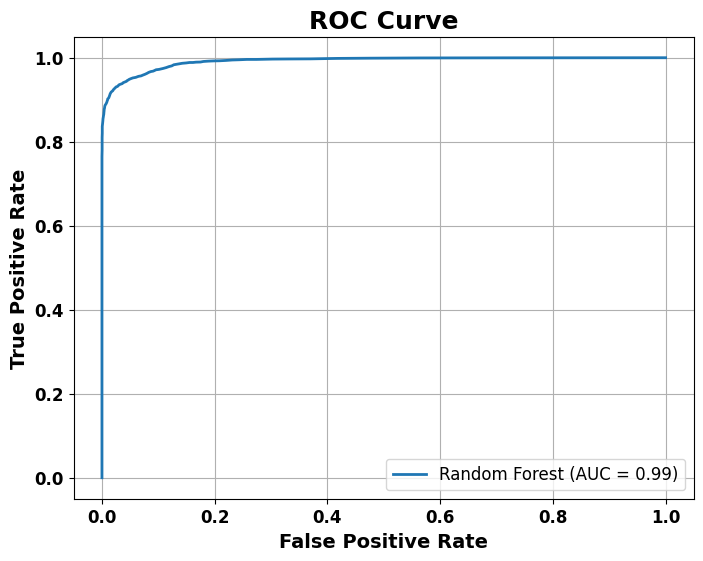

AUC Score: 0.9915


In [ ]:
# ==== ROC Curve ====
fpr, tpr, _ = roc_curve(y_test, y_prob1)
auc_score = roc_auc_score(y_test, y_prob1)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'Random Forest (AUC = {auc_score:.2f})', linewidth=2)
plt.xlabel('False Positive Rate', fontsize=14, fontweight='bold')
plt.ylabel('True Positive Rate', fontsize=14, fontweight='bold')
plt.title('ROC Curve', fontsize=18, fontweight='bold')
plt.xticks(fontsize=12, fontweight='bold')
plt.yticks(fontsize=12, fontweight='bold')
plt.grid(True)
plt.legend(fontsize=12)
plt.show()

print("AUC Score:", round(auc_score, 4))

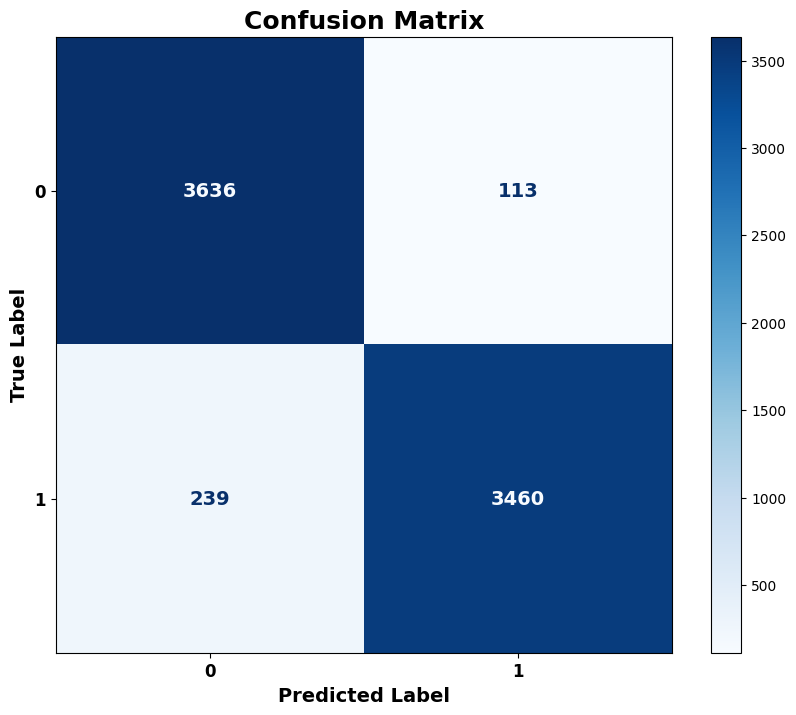

In [ ]:
# ==== Confusion Matrix ====
cm = confusion_matrix(y_test, y_pred1)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
fig, ax = plt.subplots(figsize=(10, 8))
disp.plot(cmap='Blues', ax=ax, values_format='d')
plt.title('Confusion Matrix', fontsize=18, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=14, fontweight='bold')
ax.set_xticklabels(ax.get_xticklabels(), fontsize=12, fontweight='bold')
ax.set_yticklabels(ax.get_yticklabels(), fontsize=12, fontweight='bold')
for text in disp.text_.ravel():
    text.set_fontsize(14)
    text.set_fontweight('bold')
plt.show()


 95%|=================== | 190/200 [00:19<00:01]       

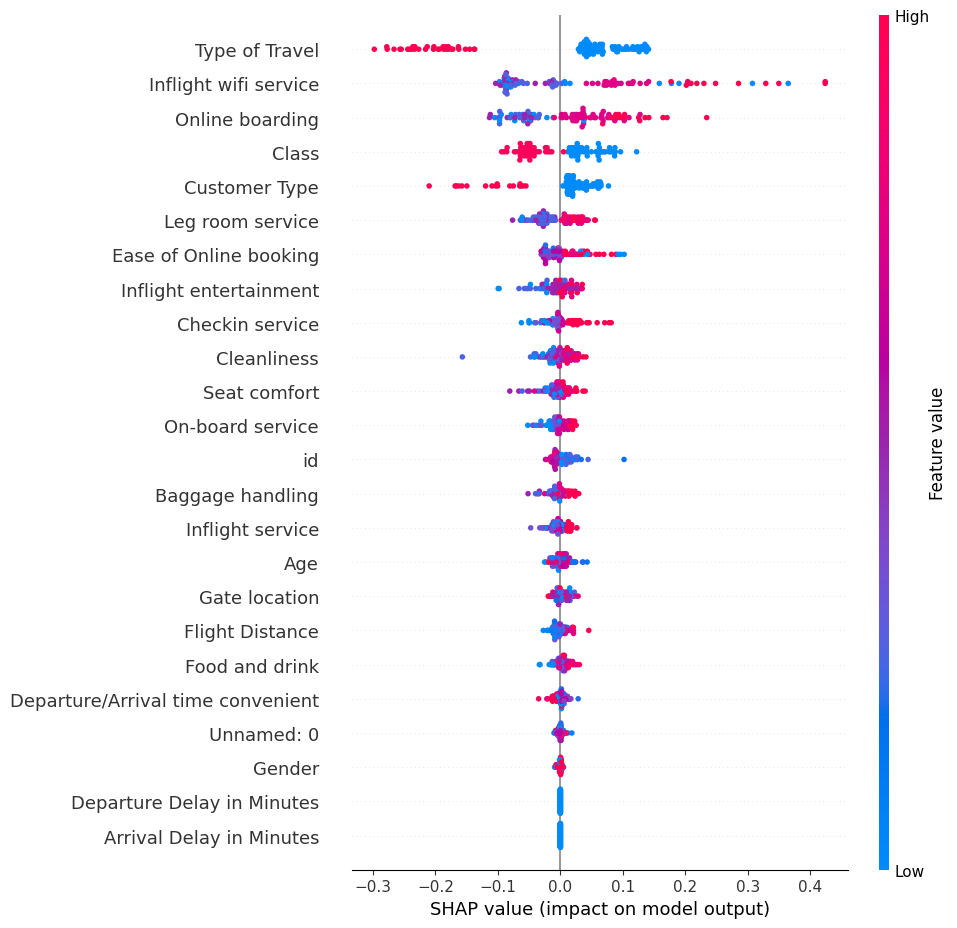

In [ ]:
# ==== SHAP Explanation ====
explainer = shap.Explainer(rf1, X_train)  # Use training data for background
shap_values = explainer(X_test[:100], check_additivity=False)  # Disable strict SHAP check

# Select SHAP values for a specific class (e.g., class 1)
shap_values_class1 = shap_values[:, :, 1]  # Assuming class 1 is the positive class

# Generate the beeswarm plot using the single-class SHAP values
shap.plots.beeswarm(shap_values_class1, max_display=len(X.columns))

In [ ]:
# ==== LIME Explanation ====
explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train_scaled,
    feature_names=X.columns,
    class_names=["Dissatisfied", "Satisfied"],
    mode='classification'
)

# Access the second row (index 1) of X_test_scaled correctly
#instance_to_explain = X_test_scaled[1, :] # Incorrect for DataFrames
instance_to_explain = X_test_scaled.iloc[1].values  # Correct way to get row values as NumPy array

# instance_to_explain = X_test_scaled[1,:] if X_test_scaled is a numpy array
# or instance_to_explain = X_test_scaled.iloc[[1]].values[0] if it is a DataFrame

exp = explainer.explain_instance(instance_to_explain, rf1.predict_proba, num_features=len(X.columns))  # Updated: use num_features
exp.show_in_notebook()

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


# **3rd Model XGBoost Classifier**

In [ ]:
import time
import shap
import lime.lime_tabular
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                             roc_curve, roc_auc_score, confusion_matrix,
                             ConfusionMatrixDisplay, matthews_corrcoef)
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.preprocessing import StandardScaler

In [ ]:
# Separate features and target
X = df_smote.drop('satisfaction', axis=1)
y = df_smote['satisfaction']

In [ ]:
# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# **-------------------------------**
# **Stage 1: Baseline XGBoost (No Scaling)**
# **-------------------------------**

In [ ]:
start1 = time.time()
model1 = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
model1.fit(X_train, y_train)
train_time1 = time.time() - start1

start_pred1 = time.time()
y_pred1 = model1.predict(X_test)
pred_time1 = time.time() - start_pred1

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [06:17:50] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


In [ ]:
print("\n=== Stage 1: Baseline XGBoost ===")
print(f"Train Accuracy: {accuracy_score(y_train, model1.predict(X_train)):.4f}")
print(f"Test Accuracy: {accuracy_score(y_test, y_pred1):.4f}")
print(f"Training Time: {train_time1:.4f} seconds")
print(f"Prediction Time: {pred_time1:.4f} seconds")
print("\nClassification Report:\n", classification_report(y_test, y_pred1))


=== Stage 1: Baseline XGBoost ===
Train Accuracy: 0.9844
Test Accuracy: 0.9617
Training Time: 21.8896 seconds
Prediction Time: 0.3483 seconds

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.97      0.96      6864
           1       0.97      0.95      0.96      6942

    accuracy                           0.96     13806
   macro avg       0.96      0.96      0.96     13806
weighted avg       0.96      0.96      0.96     13806



# **-------------------------------**
# **Stage 2: Scaled Features**
# **-------------------------------**

In [ ]:

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

start2 = time.time()
model2 = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
model2.fit(X_train_scaled, y_train)
train_time2 = time.time() - start2

start_pred2 = time.time()
y_pred2 = model2.predict(X_test_scaled)
pred_time2 = time.time() - start_pred2

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [06:18:13] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


In [ ]:
print("\n=== Stage 2: Scaled Features ===")
print(f"Train Accuracy: {accuracy_score(y_train, model2.predict(X_train_scaled)):.4f}")
print(f"Test Accuracy: {accuracy_score(y_test, y_pred2):.4f}")
print(f"Training Time: {train_time2:.4f} seconds")
print(f"Prediction Time: {pred_time2:.4f} seconds")
print("\nClassification Report:\n", classification_report(y_test, y_pred2))


=== Stage 2: Scaled Features ===
Train Accuracy: 0.9844
Test Accuracy: 0.9617
Training Time: 18.0742 seconds
Prediction Time: 0.1400 seconds

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.97      0.96      6864
           1       0.97      0.95      0.96      6942

    accuracy                           0.96     13806
   macro avg       0.96      0.96      0.96     13806
weighted avg       0.96      0.96      0.96     13806



# **-------------------------------**
# **Stage 3: Cross-Validation**
# **-------------------------------**

In [ ]:
X_scaled_cv = scaler.fit_transform(X)

model3 = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
start3 = time.time()
cv_scores = cross_val_score(model3, X_scaled_cv, y, cv=5, scoring='accuracy')
train_time3 = time.time() - start3

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [06:18:32] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [06:18:58] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [06:19:28] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [06:19:51] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [06:20:17] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_e

In [ ]:

print("\n=== Stage 3: Cross-Validated XGBoost ===")
print(f"CV Scores: {cv_scores}")
print(f"Mean CV Accuracy: {cv_scores.mean():.4f}")
print(f"CV Training Time: {train_time3:.4f} seconds")


=== Stage 3: Cross-Validated XGBoost ===
CV Scores: [0.90902506 0.924598   0.90047805 0.82890257 0.65056139]
Mean CV Accuracy: 0.8427
CV Training Time: 121.1869 seconds


# **-------------------------------**
# **Stage 1: Baseline XGBoost (No Scaling) Best Accuracy**
# **-------------------------------**

In [ ]:
# Calculate the confusion matrix
cm = confusion_matrix(y_test, y_pred2)  # Assuming y_test and y_pred2 are defined

# Now you can use cm:
tn, fp, fn, tp = cm.ravel()
specificity = tn / (tn + fp)
print("Specificity:", specificity)
print("MCC:", matthews_corrcoef(y_test, y_pred2))

Specificity: 0.9723193473193473
MCC: 0.9235886890973396


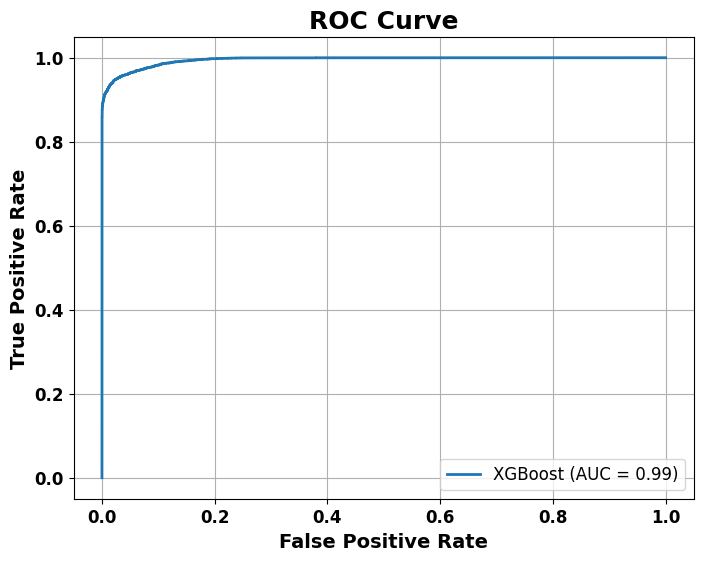

AUC Score: 0.9949


In [ ]:
# -------------------------------
# ROC Curve + AUC
# -------------------------------

y_prob = model2.predict_proba(X_test_scaled)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'XGBoost (AUC = {auc_score:.2f})', linewidth=2)
plt.xlabel('False Positive Rate', fontsize=14, fontweight='bold')
plt.ylabel('True Positive Rate', fontsize=14, fontweight='bold')
plt.title('ROC Curve', fontsize=18, fontweight='bold')
plt.xticks(fontsize=12, fontweight='bold')
plt.yticks(fontsize=12, fontweight='bold')
plt.grid(True)
plt.legend(fontsize=12)
plt.show()

print("AUC Score:", round(auc_score, 4))

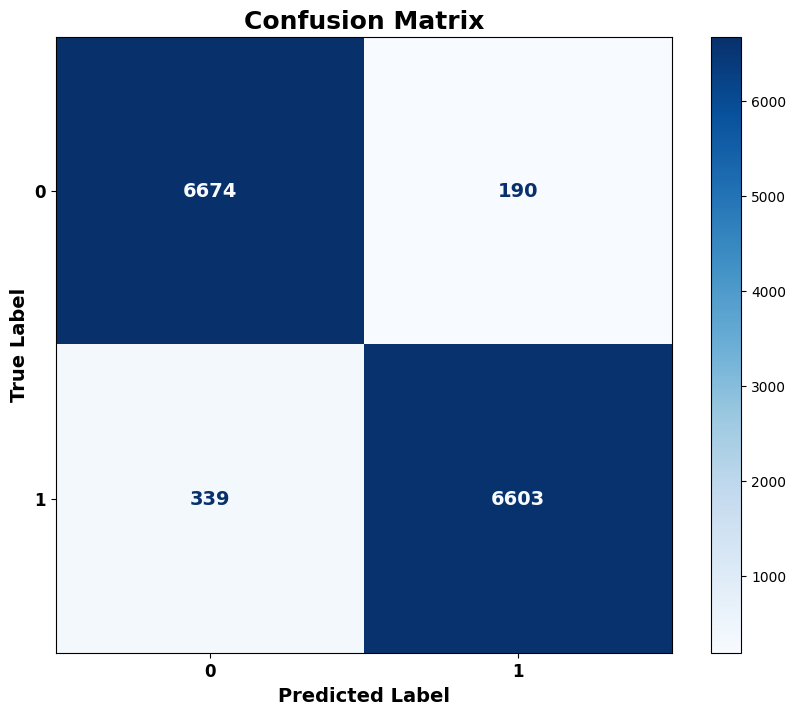

In [ ]:
# -------------------------------
# Confusion Matrix, Specificity, MCC
# -------------------------------

cm = confusion_matrix(y_test, y_pred2)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
fig, ax = plt.subplots(figsize=(10, 8))
disp.plot(cmap='Blues', ax=ax, values_format='d')
plt.title('Confusion Matrix', fontsize=18, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=14, fontweight='bold')
ax.set_xticklabels(ax.get_xticklabels(), fontsize=12, fontweight='bold')
ax.set_yticklabels(ax.get_yticklabels(), fontsize=12, fontweight='bold')
for text in disp.text_.ravel():
    text.set_fontsize(14)
    text.set_fontweight('bold')
plt.show()



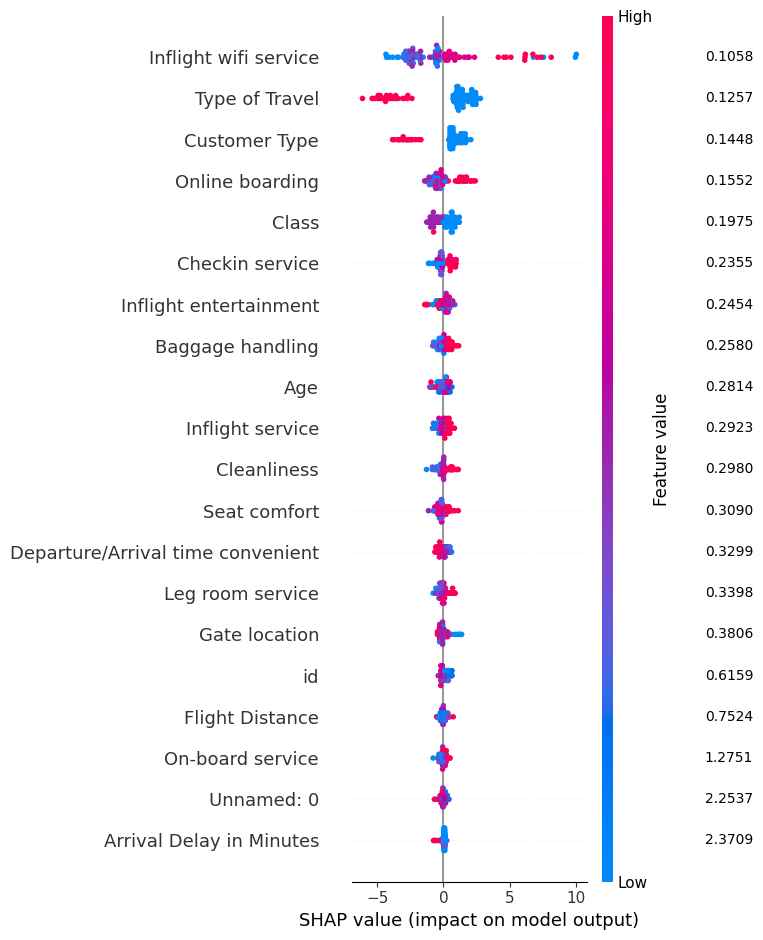

In [ ]:
# Convert scaled data back to DataFrames with original feature names
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns)

# Create SHAP explainer using model and training data
explainer = shap.Explainer(model2, X_train_scaled)

# Compute SHAP values for a subset of the test set
shap_values = explainer(X_test_scaled[:100])

# Get feature names
feature_names = X.columns

# Compute mean absolute SHAP values
mean_shap_vals = np.abs(shap_values.values).mean(axis=0)

# Create SHAP summary plot but don't show yet
shap.summary_plot(shap_values, X_test_scaled[:100], feature_names=feature_names, show=False)

# Sort feature importances
sorted_idx = np.argsort(mean_shap_vals)[::-1]
sorted_vals = mean_shap_vals[sorted_idx]
sorted_features = feature_names[sorted_idx]

# Get axis to annotate
ax = plt.gca()
yticks = ax.get_yticks()

# Add SHAP value texts at the end of each line (axis-relative to prevent overlap)
for y, val in zip(yticks, sorted_vals):
    ax.text(1.5, y, f"{val:.4f}", va='center', ha='left',
            fontsize=10, color='black', transform=ax.get_yaxis_transform())

# Tight layout for clean output
plt.tight_layout()
plt.show()

In [ ]:


lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train_scaled,
    feature_names=X.columns,
    class_names=["Dissatisfied", "Satisfied"],
    mode='classification'
)
lime_exp = lime_explainer.explain_instance(X_test_scaled[1], model2.predict_proba)
lime_exp.show_in_notebook()

# **-------------------------------**
# **XGBoost Accuracy Improvement Plan (Level-wise)**
# **-------------------------------**

In [ ]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# **-------------------------------**
# **Level 0 – Base Model (No tuning)**
# **-------------------------------**

In [ ]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import time

# Assuming 'df_smote' is your DataFrame after applying SMOTE
# Separate features and target
X = df_smote.drop('satisfaction', axis=1)
y = df_smote['satisfaction']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

start = time.time()
model = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
model.fit(X_train, y_train)
end = time.time()

train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

print("Train Accuracy:", accuracy_score(y_train, train_pred))
print("Test Accuracy:", accuracy_score(y_test, test_pred))
print("Execution Time:", round(end - start, 2), "seconds")

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [19:19:10] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Train Accuracy: 0.9831226685016841
Test Accuracy: 0.9601622482978415
Execution Time: 0.89 seconds


# **Level 1: Basic Tuning**

In [ ]:
import xgboost as xgb
from sklearn.model_selection import train_test_split, GridSearchCV # Import GridSearchCV
from sklearn.metrics import accuracy_score
import time

# Assuming 'df_smote' is your DataFrame after applying SMOTE
# Separate features and target
X = df_smote.drop('satisfaction', axis=1)
y = df_smote['satisfaction']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

start = time.time()
model = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
model.fit(X_train, y_train)
end = time.time()

train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

print("Train Accuracy:", accuracy_score(y_train, train_pred))
print("Test Accuracy:", accuracy_score(y_test, test_pred))
print("Execution Time:", round(end - start, 2), "seconds")




/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [19:31:13] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Train Accuracy: 0.9831226685016841
Test Accuracy: 0.9601622482978415
Execution Time: 0.86 seconds


In [ ]:
param_grid = {
    'max_depth': [3, 5],
    'n_estimators': [50, 100]
}

search = GridSearchCV(
    XGBClassifier(use_label_encoder=False, eval_metric='logloss'),
    param_grid,
    cv=3,
    scoring='accuracy'
)

start = time.time()
search.fit(X_train, y_train)
end = time.time()

model1 = search.best_estimator_
train_pred = model1.predict(X_train)
test_pred = model1.predict(X_test)

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [19:30:57] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [19:30:57] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [19:30:58] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [19:30:58] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [19:30:58] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_e

In [ ]:

print("Train Accuracy (Level 1):", accuracy_score(y_train, train_pred))
print("Test Accuracy (Level 1):", accuracy_score(y_test, test_pred))
print("Execution Time:", round(end - start, 2), "seconds")

Train Accuracy (Level 1): 0.9831226685016841
Test Accuracy (Level 1): 0.9601622482978415
Execution Time: 0.86 seconds


# **Level 2: Intermediate Tuning**

In [ ]:
!pip install scikit-learn

In [ ]:
import xgboost as xgb
from sklearn.model_selection import train_test_split, RandomizedSearchCV # Import RandomizedSearchCV
from sklearn.metrics import accuracy_score
import time

# Assuming 'df_smote' is your DataFrame after applying SMOTE
# Separate features and target
X = df_smote.drop('satisfaction', axis=1)
y = df_smote['satisfaction']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

start = time.time()
model = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
model.fit(X_train, y_train)
end = time.time()

train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

print("Train Accuracy:", accuracy_score(y_train, train_pred))
print("Test Accuracy:", accuracy_score(y_test, test_pred))
print("Execution Time:", round(end - start, 2), "seconds")

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [19:33:20] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Train Accuracy: 0.9831226685016841
Test Accuracy: 0.9601622482978415
Execution Time: 0.84 seconds


In [ ]:
param_grid = {
    'max_depth': [3, 5, 7],
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

search = RandomizedSearchCV(
    XGBClassifier(use_label_encoder=False, eval_metric='logloss'),
    param_distributions=param_grid,
    n_iter=10,
    cv=3,
    scoring='accuracy',
    verbose=1
)

start = time.time()
search.fit(X_train, y_train)
end = time.time()

model2 = search.best_estimator_
train_pred = model2.predict(X_train)
test_pred = model2.predict(X_test)

Fitting 3 folds for each of 10 candidates, totalling 30 fits


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [19:33:31] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [19:33:32] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [19:33:32] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [19:33:33] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [19:33:34] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_e

In [ ]:
print("Train Accuracy (Level 2):", accuracy_score(y_train, train_pred))
print("Test Accuracy (Level 2):", accuracy_score(y_test, test_pred))
print("Execution Time:", round(end - start, 2), "seconds")

Train Accuracy (Level 2): 0.9684546014269675
Test Accuracy (Level 2): 0.96045197740113
Execution Time: 35.16 seconds


# **Level 3: Advanced Tuning**

In [ ]:
param_grid = {
    'max_depth': [5, 6, 7, 8],
    'n_estimators': [100, 150, 200],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'gamma': [0, 0.1, 0.2],
    'reg_alpha': [0, 0.1, 0.5],
    'reg_lambda': [1, 1.5, 2]
}

search = RandomizedSearchCV(
    XGBClassifier(use_label_encoder=False, eval_metric='logloss'),
    param_distributions=param_grid,
    n_iter=20,
    cv=5,
    scoring='accuracy',
    verbose=2
)

start = time.time()
search.fit(X_train, y_train)
end = time.time()

model3 = search.best_estimator_
train_pred = model3.predict(X_train)
test_pred = model3.predict(X_test)



Fitting 5 folds for each of 20 candidates, totalling 100 fits


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [19:35:12] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


[CV] END colsample_bytree=0.6, gamma=0.1, learning_rate=0.1, max_depth=8, n_estimators=200, reg_alpha=0.1, reg_lambda=1.5, subsample=0.8; total time=   1.7s


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [19:35:13] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


[CV] END colsample_bytree=0.6, gamma=0.1, learning_rate=0.1, max_depth=8, n_estimators=200, reg_alpha=0.1, reg_lambda=1.5, subsample=0.8; total time=   1.7s


...

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [19:37:46] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


[CV] END colsample_bytree=1.0, gamma=0.1, learning_rate=0.01, max_depth=5, n_estimators=150, reg_alpha=0, reg_lambda=1.5, subsample=1.0; total time=   4.0s


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [19:37:50] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


[CV] END colsample_bytree=1.0, gamma=0.1, learning_rate=0.01, max_depth=5, n_estimators=150, reg_alpha=0, reg_lambda=1.5, subsample=1.0; total time=   1.0s


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [19:37:51] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


In [ ]:
print("Train Accuracy (Level 3):", accuracy_score(y_train, train_pred))
print("Test Accuracy (Level 3):", accuracy_score(y_test, test_pred))
print("Execution Time:", round(end - start, 2), "seconds")


Train Accuracy (Level 3): 0.9758972873130274
Test Accuracy (Level 3): 0.9647254816746342
Execution Time: 161.57 seconds
